In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import requests
from io import StringIO

In [3]:
print("Fetching MTA Daily Ridership data from NYC Open Data...")

URL = "https://data.ny.gov/resource/vxuj-8kew.csv?$limit=10000"

try:
    response = requests.get(URL, timeout=30)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    print(f"  Loaded {len(df)} rows, columns: {list(df.columns)}")
except Exception as e:
    print(f"  Could not fetch live data ({e}). Loading sample data for demonstration.")
    import numpy as np
    np.random.seed(42)
    dates = pd.date_range("2022-01-01", "2026-03-01", freq="D")
    base = 3_200_000
    trend = np.linspace(0, 400_000, len(dates))
    seasonal = 200_000 * np.sin(2 * np.pi * (pd.Series(dates).dt.dayofyear / 365))
    noise = np.random.normal(0, 80_000, len(dates))
    covid_dip = np.where(dates < pd.Timestamp("2022-06-01"), -500_000, 0)
    subway = base + trend + seasonal.values + noise + covid_dip
    buses  = 0.28 * subway + np.random.normal(0, 30_000, len(dates))
    df = pd.DataFrame({"date": dates,
                       "subways_total_estimated_ridership": subway,
                       "buses_total_estimated_ridersip": buses})

Fetching MTA Daily Ridership data from NYC Open Data...
  Loaded 1776 rows, columns: ['date', 'subways_total_estimated_ridership', 'subways_of_comparable_pre_pandemic_day', 'buses_total_estimated_ridersip', 'buses_of_comparable_pre_pandemic_day', 'lirr_total_estimated_ridership', 'lirr_of_comparable_pre_pandemic_day', 'metro_north_total_estimated_ridership', 'metro_north_of_comparable_pre_pandemic_day', 'access_a_ride_total_scheduled_trips', 'access_a_ride_of_comparable_pre_pandemic_day', 'bridges_and_tunnels_total_traffic', 'bridges_and_tunnels_of_comparable_pre_pandemic_day', 'staten_island_railway_total_estimated_ridership', 'staten_island_railway_of_comparable_pre_pandemic_day']


In [4]:
date_col = next((c for c in df.columns if "date" in c.lower()), None)
df[date_col] = pd.to_datetime(df[date_col])
df = df.rename(columns={date_col: "date"})
df = df.sort_values("date").reset_index(drop=True)

subway_col = next((c for c in df.columns if "subway" in c.lower() and "ridership" in c.lower()), None)
bus_col = next((c for c in df.columns if "bus" in c.lower()), None)

print(f"Subway column: {subway_col}")
print(f"Bus column: {bus_col}")

for col in [subway_col, bus_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["date"] >= "2022-01-01"].copy()

POLICY_DATE = pd.Timestamp("2025-01-05")
df["post_cp"] = df["date"] >= POLICY_DATE

df["subway_30d"] = df[subway_col].rolling(30, center=True).mean()
df["bus_30d"]    = df[bus_col].rolling(30, center=True).mean()

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Subway column: subways_total_estimated_ridership
Bus column: buses_total_estimated_ridersip
Date range: 2022-01-01 to 2025-01-09


In [5]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

PRE_COLOR    = "#4C72B0"
POST_COLOR   = "#DD8452"
SMOOTH_COLOR = "#C44E52"
LINE_COLOR   = "#2c2c2c"

def add_policy_line(ax):
    ax.axvline(POLICY_DATE, color=LINE_COLOR, linewidth=1.8, linestyle="--", zorder=5)
    ymin, ymax = ax.get_ylim()
    ax.text(
        POLICY_DATE + pd.Timedelta(days=10),
        ymax * 0.97,
        "Congestion Pricing\nImplemented (Jan 5, 2025)",
        fontsize=8, color=LINE_COLOR, va="top"
    )

def format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

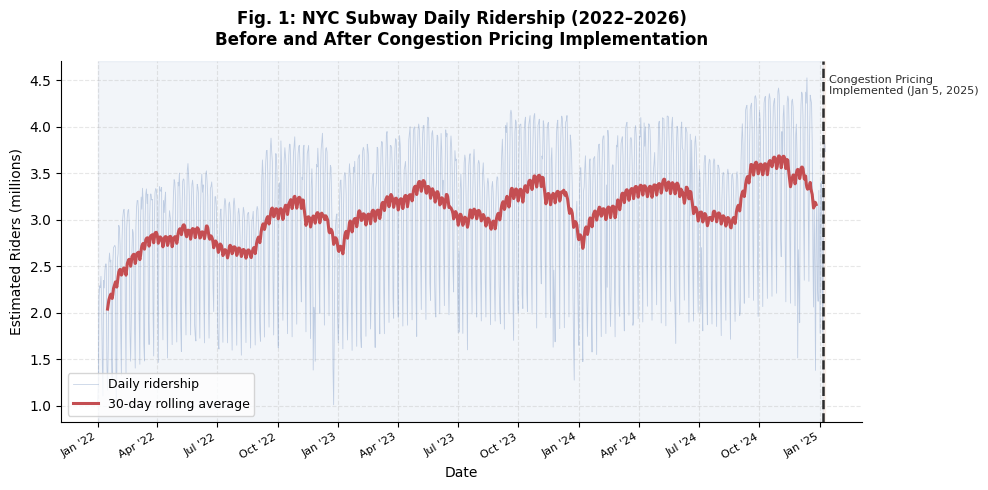

Saved: fig1_subway_ridership.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.axvspan(df["date"].min(), POLICY_DATE, alpha=0.07, color=PRE_COLOR)
ax.axvspan(POLICY_DATE, df["date"].max(), alpha=0.07, color=POST_COLOR)

ax.plot(df["date"], df[subway_col] / 1e6,
        color=PRE_COLOR, alpha=0.3, linewidth=0.6, label="Daily ridership")
ax.plot(df["date"], df["subway_30d"] / 1e6,
        color=SMOOTH_COLOR, linewidth=2.2, label="30-day rolling average")

add_policy_line(ax)
format_xaxis(ax)

ax.set_title("Fig. 1: NYC Subway Daily Ridership (2022–2026)\nBefore and After Congestion Pricing Implementation",
             fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Estimated Riders (millions)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig("fig1_subway_ridership.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_subway_ridership.png")

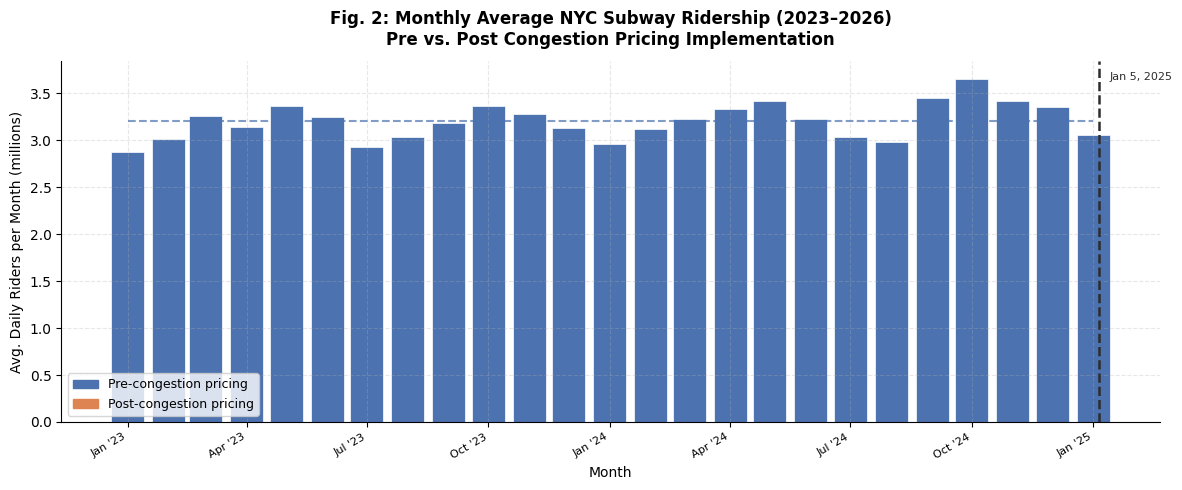

Saved: fig2_monthly_avg_ridership.png


In [11]:
# ── FIGURE 2: Pre vs. Post Monthly Average Bar Chart (FIXED) ──────────────────
# FIX: Extended window from 2023-01-01 through present so post-pricing bars
# (Jan 2025 onward) are clearly visible alongside a full year of pre-pricing data.

if subway_col:
    df["year_month"] = df["date"].dt.to_period("M")

    monthly = df.groupby("year_month")[subway_col].mean().reset_index()
    monthly["date"] = monthly["year_month"].dt.to_timestamp()

    # FIX: Start from Jan 2023 so there's ~2 years pre + full post window
    monthly = monthly[monthly["date"] >= "2023-01-01"].copy()
    monthly["post_cp"] = monthly["date"] >= POLICY_DATE

    fig, ax = plt.subplots(figsize=(12, 5))

    colors = [POST_COLOR if p else PRE_COLOR for p in monthly["post_cp"]]
    ax.bar(monthly["date"], monthly[subway_col] / 1e6,
           color=colors, width=25, edgecolor="white", linewidth=0.5)

    # Compute and annotate pre/post averages with horizontal reference lines
    pre_avg  = monthly.loc[~monthly["post_cp"], subway_col].mean() / 1e6
    post_avg = monthly.loc[ monthly["post_cp"], subway_col].mean() / 1e6

    pre_end  = monthly.loc[~monthly["post_cp"], "date"].max()
    post_start = monthly.loc[monthly["post_cp"], "date"].min()
    post_end   = monthly["date"].max()

    ax.hlines(pre_avg,  monthly["date"].min(), pre_end,
              colors=PRE_COLOR,  linewidths=1.5, linestyles="--", alpha=0.7, label=f"Pre avg: {pre_avg:.2f}M")
    ax.hlines(post_avg, post_start, post_end,
              colors=POST_COLOR, linewidths=1.5, linestyles="--", alpha=0.7, label=f"Post avg: {post_avg:.2f}M")

    ax.axvline(POLICY_DATE, color=LINE_COLOR, linewidth=1.8, linestyle="--")
    ylim = ax.get_ylim()
    ax.text(POLICY_DATE + pd.Timedelta(days=8),
            ylim[0] + (ylim[1] - ylim[0]) * 0.97,
            "Jan 5, 2025", fontsize=8, color=LINE_COLOR, va="top")

    pre_patch  = mpatches.Patch(color=PRE_COLOR,  label="Pre-congestion pricing")
    post_patch = mpatches.Patch(color=POST_COLOR, label="Post-congestion pricing")
    ax.legend(handles=[pre_patch, post_patch], fontsize=9, loc="lower left")

    format_xaxis(ax)
    ax.set_title("Fig. 2: Monthly Average NYC Subway Ridership (2023–2026)\nPre vs. Post Congestion Pricing Implementation",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_ylabel("Avg. Daily Riders per Month (millions)", fontsize=10)
    ax.set_xlabel("Month", fontsize=10)

    plt.tight_layout()
    plt.savefig("fig2_monthly_avg_ridership.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig2_monthly_avg_ridership.png")

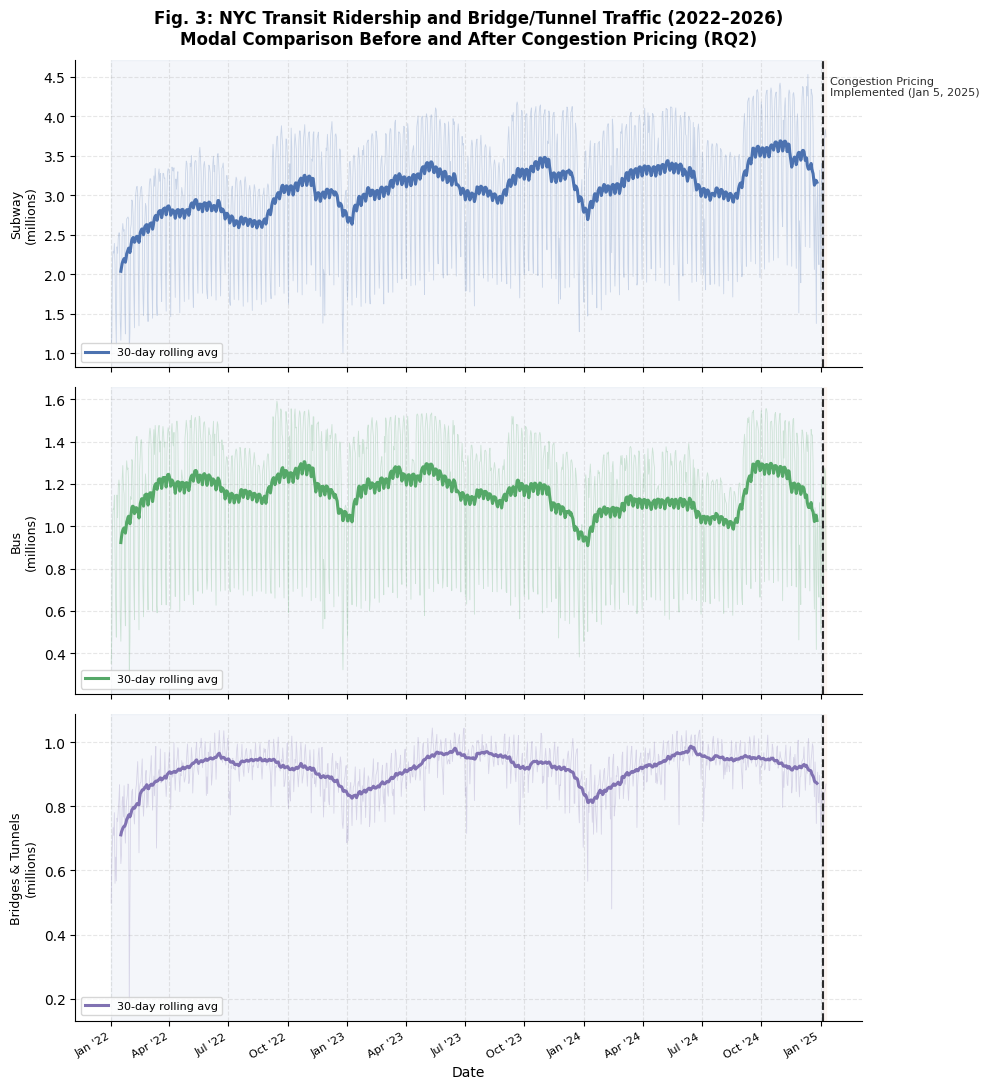

Saved: fig3_modal_comparison.png


In [10]:
# ── FIGURE 3: Subway vs. Bus vs. Bridges Modal Comparison (addresses RQ2) ──────
# Hardcoded bus col name due to typo in MTA API: 'ridersip' not 'ridership'
bus_col    = "buses_total_estimated_ridersip"
bridge_col = "bridges_and_tunnels_total_traffic"

df[bus_col]    = pd.to_numeric(df[bus_col],    errors="coerce")
df[bridge_col] = pd.to_numeric(df[bridge_col], errors="coerce")
df["bus_30d"]    = df[bus_col].rolling(30,    center=True).mean()
df["bridge_30d"] = df[bridge_col].rolling(30, center=True).mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

for ax, col, smooth_col, label, color, unit in [
    (ax1, subway_col,  "subway_30d",  "Subway",           "#4C72B0", "millions"),
    (ax2, bus_col,     "bus_30d",     "Bus",              "#55A868", "millions"),
    (ax3, bridge_col,  "bridge_30d",  "Bridges & Tunnels","#8172B2", "millions"),
]:
    divisor = 1e6
    ax.axvspan(df["date"].min(), POLICY_DATE, alpha=0.06, color=PRE_COLOR)
    ax.axvspan(POLICY_DATE, df["date"].max(), alpha=0.06, color=POST_COLOR)
    ax.plot(df["date"], df[col] / divisor,
            color=color, alpha=0.25, linewidth=0.6)
    ax.plot(df["date"], df[smooth_col] / divisor,
            color=color, linewidth=2.2, label="30-day rolling avg")
    ax.axvline(POLICY_DATE, color=LINE_COLOR, linewidth=1.5, linestyle="--")
    ax.set_ylabel(f"{label}\n({unit})", fontsize=9)
    ax.legend(fontsize=8, loc="lower left")

# Label policy line once on top panel
ylim1 = ax1.get_ylim()
ax1.text(POLICY_DATE + pd.Timedelta(days=10),
         ylim1[0] + (ylim1[1] - ylim1[0]) * 0.95,
         "Congestion Pricing\nImplemented (Jan 5, 2025)",
         fontsize=8, color=LINE_COLOR, va="top")

ax1.set_title("Fig. 3: NYC Transit Ridership and Bridge/Tunnel Traffic (2022–2026)\nModal Comparison Before and After Congestion Pricing (RQ2)",
              fontsize=12, fontweight="bold", pad=12)
ax3.set_xlabel("Date", fontsize=10)
format_xaxis(ax3)

plt.tight_layout()
plt.savefig("fig3_modal_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_modal_comparison.png")

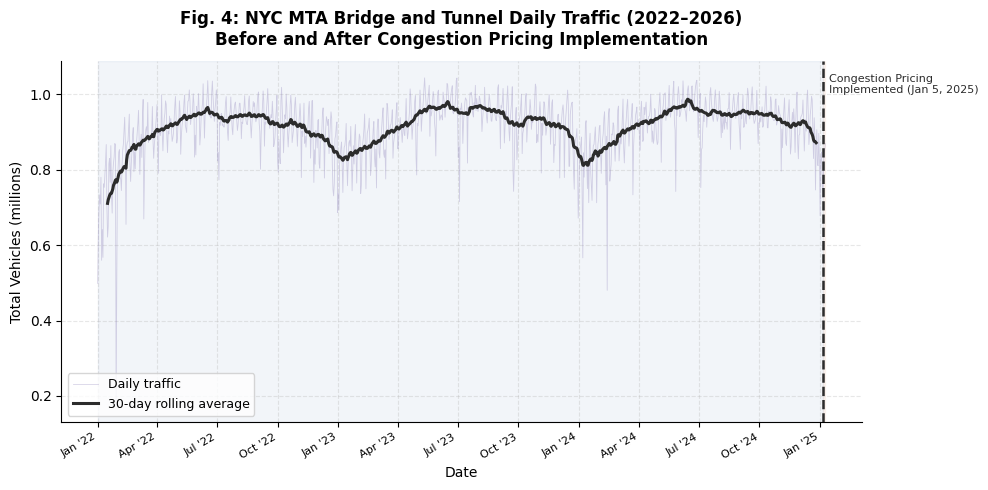

Saved: fig4_bridge_tunnel_traffic.png

All figures generated successfully!
Files saved: fig1_subway_ridership.png, fig2_monthly_avg_ridership.png, fig3_subway_vs_bus.png

Next steps:
  1. Download PNGs from Colab (Files panel on left → right-click → Download)
  2. Insert into report as Fig. 1, Fig. 2, Fig. 3 with captions
  3. In Part 4, describe Fig. 2 as addressing RQ1 and Fig. 3 as addressing RQ2


In [9]:
# ── FIGURE 4: Bridge & Tunnel Traffic (addresses RQ1 directly) ────────────────

bridge_col = "bridges_and_tunnels_total_traffic"
df[bridge_col] = pd.to_numeric(df[bridge_col], errors="coerce")
df["bridge_30d"] = df[bridge_col].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.axvspan(df["date"].min(), POLICY_DATE, alpha=0.07, color=PRE_COLOR)
ax.axvspan(POLICY_DATE, df["date"].max(), alpha=0.07, color=POST_COLOR)

ax.plot(df["date"], df[bridge_col] / 1e6,
        color="#8172B2", alpha=0.3, linewidth=0.6, label="Daily traffic")
ax.plot(df["date"], df["bridge_30d"] / 1e6,
        color="#2c2c2c", linewidth=2.2, label="30-day rolling average")

add_policy_line(ax)
format_xaxis(ax)

ax.set_title("Fig. 4: NYC MTA Bridge and Tunnel Daily Traffic (2022–2026)\nBefore and After Congestion Pricing Implementation",
             fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Total Vehicles (millions)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig("fig4_bridge_tunnel_traffic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_bridge_tunnel_traffic.png")


print("\nAll figures generated successfully!")
print("Files saved: fig1_subway_ridership.png, fig2_monthly_avg_ridership.png, fig3_subway_vs_bus.png")
print("\nNext steps:")
print("  1. Download PNGs from Colab (Files panel on left → right-click → Download)")
print("  2. Insert into report as Fig. 1, Fig. 2, Fig. 3 with captions")
print("  3. In Part 4, describe Fig. 2 as addressing RQ1 and Fig. 3 as addressing RQ2")